# Experiment 8 Follow-Up: Full Cluster Membership + Clearer Figures

Answers four follow-up questions from your professor about Experiment 8
(35 well-documented poets + 114 surahs):

1. Which surahs are in each of the 8 clusters, and which 3 are outliers?
2. Which color represents the outliers in the original graph?
3. A new graph with the outliers unambiguously marked.
4. A new graph with each surah's number labeled directly on the plot.

**Reuses your cached embeddings** if this notebook sits in the same
folder as your earlier runs (`embed_cache/`) — should be fast, no
re-embedding needed.

**Before you start:** put `poems.db` in the same folder as this
notebook.

Run cells top to bottom, **Shift+Enter**.

In [1]:
# CELL 1 -- Install packages
!pip -q install sentence-transformers torch scikit-learn umap-learn hdbscan pandas numpy matplotlib seaborn scipy requests


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2 -- Configuration
import re, sqlite3, hashlib, json, warnings, pickle
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

warnings.filterwarnings("ignore")

DB_PATH = Path("poems.db")
CACHE_DIR = Path("quran_cache"); CACHE_DIR.mkdir(exist_ok=True)
EMBED_CACHE_DIR = Path("embed_cache"); EMBED_CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("output/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("output/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("output/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SBERT_MODEL_NAME = "akhooli/Arabic-SBERT-100K"
MAX_VERSES_PER_POEM = 20

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS_HIGH = 50
UMAP_METRIC = "cosine"
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES = 3

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found -- will run on CPU (slower).")

def split_verses(poem_text):
    if not poem_text or not isinstance(poem_text, str):
        return []
    verses = re.split(r'[\n\r]+|[.!\u061F?\u061B;]+', poem_text)
    return [v.strip() for v in verses if len(v.strip()) > 10]

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 11})
print("Config loaded.")

GPU available: NVIDIA GeForce RTX 4080 SUPER
Config loaded.


In [3]:
# CELL 3 -- Load the 260 poets from poems.db
conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query(
    "SELECT poet_name, poem_title, poem_text, poem_type, poem_meter, verses_count "
    "FROM poems WHERE poet_name IS NOT NULL AND poem_text IS NOT NULL "
    "AND LENGTH(poem_text) >= 50",
    conn,
)
conn.close()

df["poem_hash"] = df["poem_text"].apply(lambda t: hashlib.md5(t.strip().encode("utf-8")).hexdigest())
df = df.drop_duplicates(subset=["poem_hash"]).copy()

poems_by_poet = defaultdict(list)
for _, row in df.iterrows():
    poems_by_poet[row["poet_name"]].append(row["poem_text"])
poems_by_poet = dict(poems_by_poet)

poet_total_verses = {
    poet: sum(len(split_verses(p)) for p in poems)
    for poet, poems in poems_by_poet.items()
}

print(f"Poets loaded: {len(poems_by_poet)}")

Poets loaded: 260


In [4]:
# CELL 4 -- Fetch Quran text + per-surah size metadata
cache_file = CACHE_DIR / "quran_ayat.json"

if cache_file.exists():
    print("Loading Quran from local cache...")
    with open(cache_file, encoding="utf-8") as f:
        surahs_raw = json.load(f)
else:
    print("Fetching Quran from Al Quran Cloud API...")
    resp = requests.get("https://api.alquran.cloud/v1/quran/quran-uthmani", timeout=60)
    resp.raise_for_status()
    surahs_raw = resp.json()["data"]["surahs"]
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(surahs_raw, f, ensure_ascii=False)
    print("Fetched and cached.")

surah_names = {}
surah_poem_text = {}
for s in surahs_raw:
    snum = s["number"]
    surah_names[snum] = s["englishName"]
    ayat_texts = [a["text"] for a in s["ayahs"]]
    surah_poem_text[snum] = "\n".join(ayat_texts)

print(f"Surahs loaded: {len(surah_poem_text)}")

Fetching Quran from Al Quran Cloud API...
Fetched and cached.
Surahs loaded: 114


In [5]:
# CELL 5 -- Embed the 260 poets (cached after first run)
from sentence_transformers import SentenceTransformer

poet_cache_file = EMBED_CACHE_DIR / "poet_embeddings.pkl"

print("Loading model:", SBERT_MODEL_NAME)
model = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded. Embedding dim:", model.get_sentence_embedding_dimension())

def _encode(texts, batch_size=64):
    if not texts:
        return np.array([])
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False,
                         normalize_embeddings=True, convert_to_numpy=True)

def embed_poem_verse_average(poems_by_author, max_verses=MAX_VERSES_PER_POEM, seed=RANDOM_SEED):
    out = {}
    rng = np.random.RandomState(seed)
    for author, poems in poems_by_author.items():
        poem_vectors = []
        for poem in poems:
            verses = split_verses(poem)
            if len(verses) > max_verses:
                idx = rng.choice(len(verses), max_verses, replace=False)
                verses = [verses[i] for i in sorted(idx)]
            if verses:
                poem_vectors.append(np.mean(_encode(verses), axis=0))
        if poem_vectors:
            out[author] = np.mean(poem_vectors, axis=0)
    return out

if poet_cache_file.exists():
    print("Loading cached poet embeddings...")
    with open(poet_cache_file, "rb") as f:
        poet_embeddings = pickle.load(f)
    print(f"Loaded {len(poet_embeddings)} cached poet embeddings.")
else:
    print("Embedding 260 poets (this is the slow step, one-time only)...")
    poet_embeddings = embed_poem_verse_average(poems_by_poet)
    with open(poet_cache_file, "wb") as f:
        pickle.dump(poet_embeddings, f)
    print(f"Done and cached. {len(poet_embeddings)} poets embedded.")

Loading model: akhooli/Arabic-SBERT-100K


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded. Embedding dim: 768
Embedding 260 poets (this is the slow step, one-time only)...
Done and cached. 260 poets embedded.


In [6]:
# CELL 6 -- Embed the 114 surahs (cached after first run)
surah_cache_file = EMBED_CACHE_DIR / "surah_vectors.pkl"

if surah_cache_file.exists():
    print("Loading cached surah embeddings...")
    with open(surah_cache_file, "rb") as f:
        surah_vectors = pickle.load(f)
    print(f"Loaded {len(surah_vectors)} cached surah embeddings.")
else:
    print("Embedding 114 surahs...")
    surah_vectors = {}
    for snum, poem_text in surah_poem_text.items():
        verses = split_verses(poem_text)
        if verses:
            surah_vectors[snum] = np.mean(_encode(verses), axis=0)
    with open(surah_cache_file, "wb") as f:
        pickle.dump(surah_vectors, f)
    print(f"Done and cached. {len(surah_vectors)} surahs embedded.")

print(f"{len(surah_vectors)} surah vectors ready.")

Embedding 114 surahs...
Done and cached. 114 surahs embedded.
114 surah vectors ready.


## Rerun Experiment 8 (deterministic, same seed/settings as before)

In [7]:
# CELL 7 -- Rerun Experiment 8
import umap, hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

def run_umap(matrix, n_components, n_neighbors, min_dist, metric="cosine", random_state=RANDOM_SEED):
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                         min_dist=min_dist, metric=metric, random_state=random_state)
    return reducer.fit_transform(matrix)

def cluster_and_report(embeddings_dict, label_types, title, n_neighbors=UMAP_N_NEIGHBORS,
                       min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, verbose=True):
    names = sorted(embeddings_dict.keys())
    n = len(names)
    emb_matrix = np.array([embeddings_dict[nm] for nm in names])
    umap_high = run_umap(emb_matrix, min(UMAP_N_COMPONENTS_HIGH, max(2, n - 2)), n_neighbors, 0.0, UMAP_METRIC)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min(min_cluster_size, max(2, n // 10)),
                                min_samples=HDBSCAN_MIN_SAMPLES,
                                cluster_selection_method="eom", metric="euclidean")
    labels = clusterer.fit_predict(umap_high)
    umap_2d = run_umap(emb_matrix, 2, n_neighbors, UMAP_MIN_DIST, UMAP_METRIC)
    mask = labels >= 0
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    n_outliers = int(np.sum(labels == -1))
    sil = float(silhouette_score(umap_high[mask], labels[mask])) if n_clusters >= 2 and mask.sum() > n_clusters else None
    result_df = pd.DataFrame({"name": names, "type": [label_types[nm] for nm in names],
        "cluster": labels, "umap_x": umap_2d[:, 0], "umap_y": umap_2d[:, 1]})
    if verbose:
        print(f"=== {title} ===")
        print(f"Total: {n} | Clusters: {n_clusters} | Outliers: {n_outliers} | Silhouette: {sil}")
    return result_df, {"n_entities": n, "n_clusters": n_clusters, "n_outliers": n_outliers, "silhouette": sil}

max_surah_verses = max(len(split_verses(t)) for t in surah_poem_text.values())
large_poets = {p: v for p, v in poet_total_verses.items() if v > max_surah_verses}
print(f"Well-documented poets (total verses > {max_surah_verses}): {len(large_poets)} of {len(poet_total_verses)}")

exp8_embeddings = {p: poet_embeddings[p] for p in large_poets if p in poet_embeddings}
for snum, vec in surah_vectors.items():
    exp8_embeddings[f"Surah {snum}: {surah_names[snum]}"] = vec
exp8_types = {nm: ("Surah" if nm.startswith("Surah ") else "Poet") for nm in exp8_embeddings}

exp8_df, exp8_metrics = cluster_and_report(
    exp8_embeddings, exp8_types,
    f"Experiment 8: {len(large_poets)} well-documented poets + 114 surahs")

exp8_df["surah_number"] = exp8_df["name"].apply(
    lambda n: int(n.split(":")[0].replace("Surah ", "")) if n.startswith("Surah ") else None)
exp8_df.to_csv(TABLES_DIR / "experiment8_clusters_rerun.csv", index=False)

Well-documented poets (total verses > 286): 35 of 260
=== Experiment 8: 35 well-documented poets + 114 surahs ===
Total: 149 | Clusters: 9 | Outliers: 3 | Silhouette: 0.679192304611206


## Q1 — Full membership of all 8 clusters + Q2 — Outlier color

In [8]:
# CELL 8 -- Q1: full cluster membership, Q2: outlier color
print("=" * 60)
print("Q1: SURAHS IN EACH CLUSTER")
print("=" * 60)

cluster_membership = []
for cl in sorted(exp8_df["cluster"].unique()):
    members = exp8_df[exp8_df["cluster"] == cl]
    surah_members = members[members["type"] == "Surah"].sort_values("surah_number")
    poet_members = members[members["type"] == "Poet"]
    label = "OUTLIERS" if cl == -1 else f"Cluster {cl}"
    surah_list = [f"{int(r.surah_number)}:{r.name.split(': ',1)[1]}" for r in surah_members.itertuples()]
    print(f"\n{label} -- {len(surah_members)} surahs, {len(poet_members)} poets")
    if len(surah_list) > 0:
        print("  Surahs:", ", ".join(surah_list))
    if len(poet_members) > 0:
        print("  Poets:", ", ".join(poet_members["name"].tolist()))
    cluster_membership.append({"cluster": label, "n_surahs": len(surah_members), "n_poets": len(poet_members),
                               "surahs": "; ".join(surah_list), "poets": "; ".join(poet_members["name"].tolist())})

pd.DataFrame(cluster_membership).to_csv(TABLES_DIR / "exp8_full_membership.csv", index=False)

print("\n" + "=" * 60)
print("Q2: OUTLIER COLOR")
print("=" * 60)
print("In the original Experiment 8 figure, outliers (cluster == -1) were")
print("plotted in GRAY (color='gray' in the plotting code) -- the same")
print("gray used for every experiment's outlier points throughout this project.")
outlier_surahs = exp8_df[(exp8_df["type"] == "Surah") & (exp8_df["cluster"] == -1)]
print(f"\nThe 3 outlier surahs: {outlier_surahs['name'].tolist()}")

Q1: SURAHS IN EACH CLUSTER

OUTLIERS -- 3 surahs, 0 poets
  Surahs: 14:Ibrahim, 26:Ash-Shu'araa, 72:Al-Jinn

Cluster 0 -- 0 surahs, 35 poets
  Poets: أحيحة بن الجلاح, أوس بن حجر, الأسود النهشلي, الأفوة الأودي, الحارث بن حلزة, الخنساء, السموأل, الشنفرى, الطفيل الغنوي, الفند الزماني, المتلمس الضبعي, المثقب العبدي, المرقش الأكبر, المسيب بن علس, النابغة الذبياني, امرؤ القيس, بشر بن أبي خازم, تأبط شراً, حاتم الطائي, حاجز الأزدي, دريد بن الصمة, ذو الإصبع العدواني, زهير بن أبي سلمى, زيد الخيل الطائي, سلامة بن جندل, صيفي الأسلت, طرفة بن العبد, عدي بن ربيعة, عدي بن زيد, عروة بن الورد, علقمة الفحل, عمرو بن قميئة, عمرو بن كلثوم, عنترة بن شداد, قيس بن الحدادية

Cluster 1 -- 22 surahs, 0 poets
  Surahs: 1:Al-Faatiha, 56:Al-Waaqia, 74:Al-Muddaththir, 77:Al-Mursalaat, 78:An-Naba, 79:An-Naazi'aat, 80:Abasa, 81:At-Takwir, 85:Al-Burooj, 86:At-Taariq, 87:Al-A'laa, 88:Al-Ghaashiya, 90:Al-Balad, 91:Ash-Shams, 92:Al-Lail, 94:Ash-Sharh, 96:Al-Alaq, 100:Al-Aadiyaat, 101:Al-Qaari'a, 102:At-Takaathur, 107:Al-Ma

## Q3 — New graph with outliers clearly marked

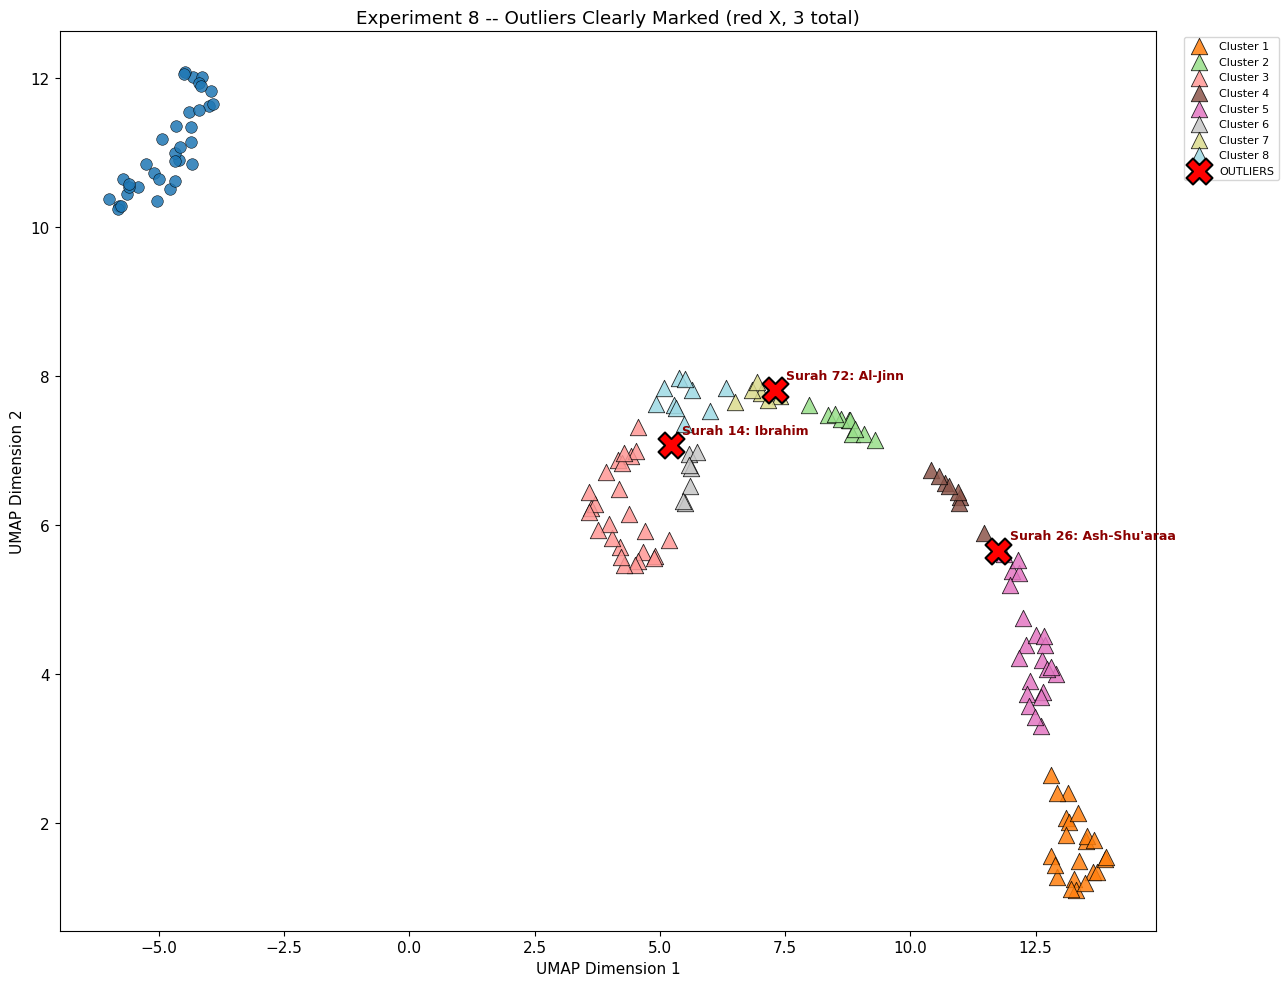

3 outliers marked in red.


In [9]:
# CELL 9 -- Q3: figure with outliers unambiguously marked
fig, ax = plt.subplots(figsize=(13, 10))
unique_clusters = sorted(exp8_df["cluster"].unique())
n_clust_plot = len([c for c in unique_clusters if c >= 0])
colors = plt.cm.tab20(np.linspace(0, 1, max(n_clust_plot, 1)))

for cl in unique_clusters:
    if cl == -1:
        continue  # plot outliers last, on top, so they're never hidden
    sub = exp8_df[exp8_df["cluster"] == cl]
    for t, marker, size, edge, lw in [("Poet", "o", 70, "black", 0.4), ("Surah", "^", 140, "black", 0.6)]:
        tsub = sub[sub["type"] == t]
        if len(tsub) == 0:
            continue
        ax.scatter(tsub["umap_x"], tsub["umap_y"], c=[colors[cl % len(colors)]], marker=marker, s=size,
                  alpha=0.85, edgecolors=edge, linewidth=lw, label=f"Cluster {cl}" if t=="Surah" else None)

# Outliers: large red X, unmistakable, drawn on top
outliers = exp8_df[exp8_df["cluster"] == -1]
ax.scatter(outliers["umap_x"], outliers["umap_y"], c="red", marker="X", s=350,
          edgecolors="black", linewidth=1.5, label="OUTLIERS", zorder=10)
for _, row in outliers.iterrows():
    label = row["name"] if row["type"] == "Surah" else row["name"]
    ax.annotate(label, (row["umap_x"], row["umap_y"]), fontsize=9, fontweight="bold",
               color="darkred", xytext=(8, 8), textcoords="offset points")

ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
ax.set_title(f"Experiment 8 -- Outliers Clearly Marked (red X, {len(outliers)} total)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp8_outliers_marked.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"{len(outliers)} outliers marked in red.")

## Q4 — New graph with surah numbers labeled

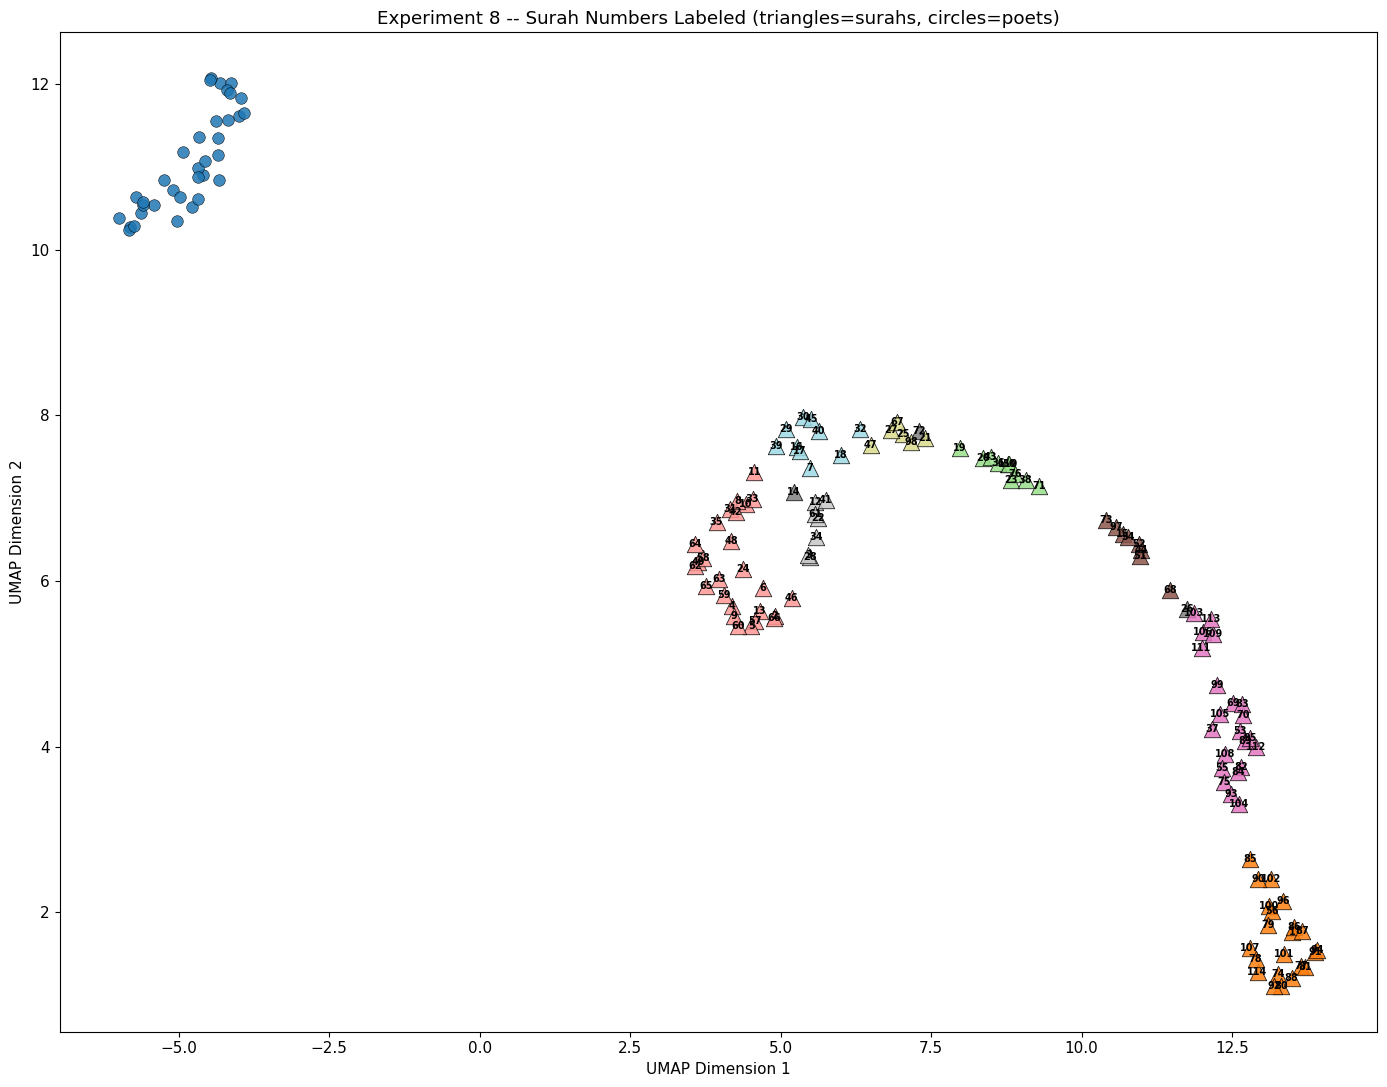

Figure saved with surah numbers labeled.


In [10]:
# CELL 10 -- Q4: figure with surah numbers labeled
fig, ax = plt.subplots(figsize=(14, 11))

for cl in unique_clusters:
    sub = exp8_df[exp8_df["cluster"] == cl]
    color = "gray" if cl == -1 else colors[cl % len(colors)]
    poet_sub = sub[sub["type"] == "Poet"]
    surah_sub = sub[sub["type"] == "Surah"]
    if len(poet_sub) > 0:
        ax.scatter(poet_sub["umap_x"], poet_sub["umap_y"], c=[color], marker="o", s=70,
                  alpha=0.85, edgecolors="black", linewidth=0.4)
    if len(surah_sub) > 0:
        ax.scatter(surah_sub["umap_x"], surah_sub["umap_y"], c=[color], marker="^", s=140,
                  alpha=0.85, edgecolors="black", linewidth=0.6)
        for _, row in surah_sub.iterrows():
            ax.annotate(str(int(row["surah_number"])), (row["umap_x"], row["umap_y"]),
                       fontsize=7, ha="center", va="center", fontweight="bold")

ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
ax.set_title("Experiment 8 -- Surah Numbers Labeled (triangles=surahs, circles=poets)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp8_surah_numbers.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved with surah numbers labeled.")

In [11]:
# CELL 11 -- Final report
report_path = REPORTS_DIR / "experiment8_followup_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("EXPERIMENT 8 FOLLOW-UP: FULL CLUSTER MEMBERSHIP\n")
    f.write("=" * 70 + "\n\n")

    f.write("Q1: SURAHS AND POETS IN EACH CLUSTER\n" + "-" * 40 + "\n")
    for row in cluster_membership:
        f.write(f"\n{row['cluster']} ({row['n_surahs']} surahs, {row['n_poets']} poets)\n")
        if row["surahs"]:
            f.write(f"  Surahs: {row['surahs']}\n")
        if row["poets"]:
            f.write(f"  Poets: {row['poets']}\n")

    f.write("\nQ2: OUTLIER COLOR\n" + "-" * 40 + "\n")
    f.write("  Gray, in the original figure -- same convention used throughout\n")
    f.write("  every experiment in this project.\n")
    f.write(f"  The 3 outlier surahs: {outlier_surahs['name'].tolist()}\n")

    f.write("\nQ3 and Q4: see the two new figures in output/figures/\n" + "-" * 40 + "\n")
    f.write("  exp8_outliers_marked.png -- outliers as large red X markers\n")
    f.write("  exp8_surah_numbers.png -- every surah labeled with its number\n")

print(f"Report written to {report_path}")
print()
print(open(report_path, encoding="utf-8").read())

Report written to output\reports\experiment8_followup_report.txt

EXPERIMENT 8 FOLLOW-UP: FULL CLUSTER MEMBERSHIP

Q1: SURAHS AND POETS IN EACH CLUSTER
----------------------------------------

OUTLIERS (3 surahs, 0 poets)
  Surahs: 14:Ibrahim; 26:Ash-Shu'araa; 72:Al-Jinn

Cluster 0 (0 surahs, 35 poets)
  Poets: أحيحة بن الجلاح; أوس بن حجر; الأسود النهشلي; الأفوة الأودي; الحارث بن حلزة; الخنساء; السموأل; الشنفرى; الطفيل الغنوي; الفند الزماني; المتلمس الضبعي; المثقب العبدي; المرقش الأكبر; المسيب بن علس; النابغة الذبياني; امرؤ القيس; بشر بن أبي خازم; تأبط شراً; حاتم الطائي; حاجز الأزدي; دريد بن الصمة; ذو الإصبع العدواني; زهير بن أبي سلمى; زيد الخيل الطائي; سلامة بن جندل; صيفي الأسلت; طرفة بن العبد; عدي بن ربيعة; عدي بن زيد; عروة بن الورد; علقمة الفحل; عمرو بن قميئة; عمرو بن كلثوم; عنترة بن شداد; قيس بن الحدادية

Cluster 1 (22 surahs, 0 poets)
  Surahs: 1:Al-Faatiha; 56:Al-Waaqia; 74:Al-Muddaththir; 77:Al-Mursalaat; 78:An-Naba; 79:An-Naazi'aat; 80:Abasa; 81:At-Takwir; 85:Al-Burooj; 86:At-

## Done

Output in `output/`:
- `output/tables/exp8_full_membership.csv` — every cluster's full membership
- `output/figures/exp8_outliers_marked.png` — Q3's figure
- `output/figures/exp8_surah_numbers.png` — Q4's figure
- `output/reports/experiment8_followup_report.txt` — all four answers together